In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

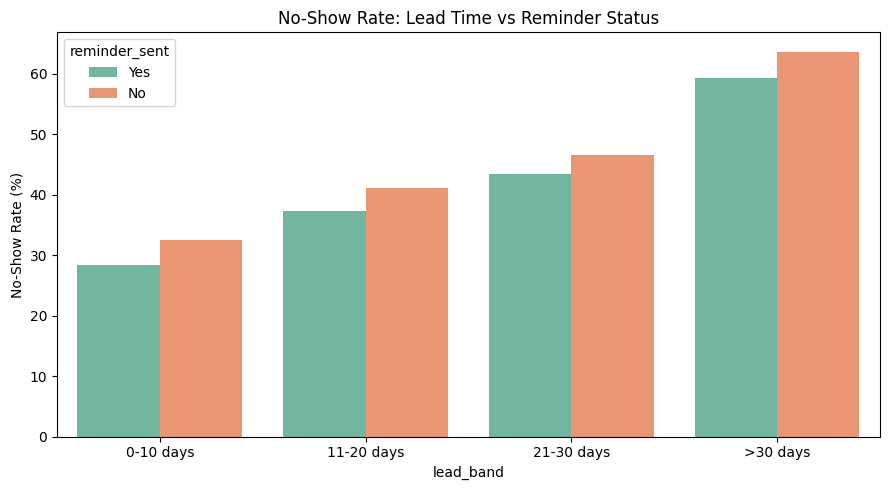

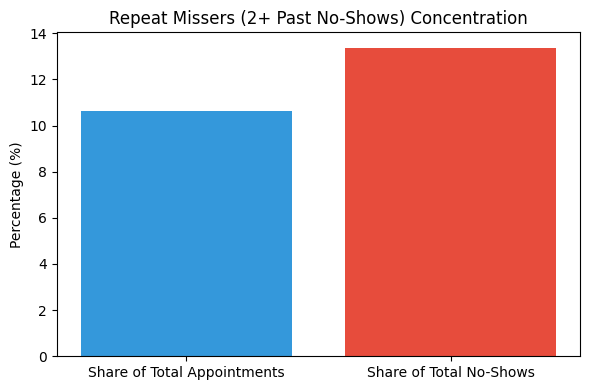

/tmp/ipykernel_860/2472357653.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df.loc[far, 'appointment_type'], palette='Set3')


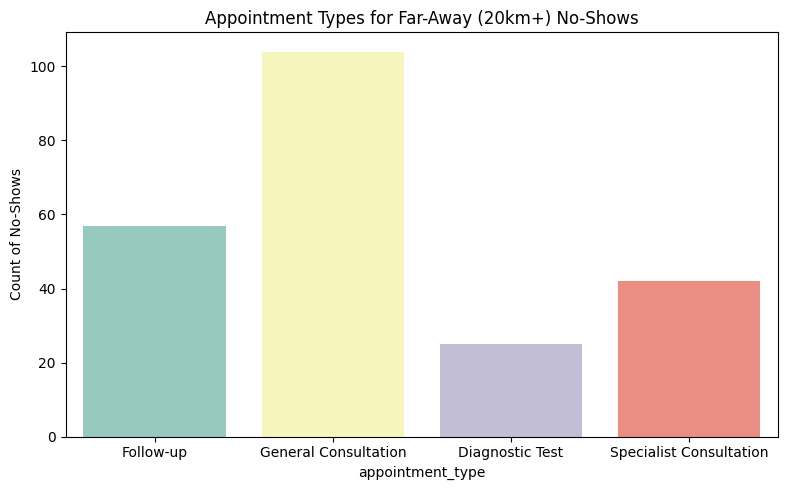

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Load the dataset
df = pd.read_csv('HealthConnect_Appointment_Data.csv')

is_ns = (df['appointment_outcome'] == 'No-Show').astype(int)
ns_pct = is_ns * 100
lead = pd.cut(df['booking_lead_days'], bins=[-1, 10, 20, 30, 60],
              labels=['0-10 days', '11-20 days', '21-30 days', '>30 days'])

# --- Chart 7 ---
plt.figure(figsize=(9,5))
sns.barplot(x=lead, y=ns_pct, hue=df['reminder_sent'], palette='Set2', errorbar=None)
plt.title('No-Show Rate: Lead Time vs Reminder Status')
plt.ylabel('No-Show Rate (%)'); plt.xlabel('lead_band')
plt.tight_layout()
plt.savefig('Chart7_LeadTime_vs_Reminder.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Chart 8---
mask = df['previous_no_shows'] >= 2
vals = [100*mask.mean(), 100*is_ns[mask].sum()/is_ns.sum()]
plt.figure(figsize=(6,4))
plt.bar(['Share of Total Appointments','Share of Total No-Shows'], vals,
        color=['#3498db','#e74c3c'])
plt.title('Repeat Missers (2+ Past No-Shows) Concentration')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.savefig('Chart8_RepeatMissers.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Chart 9 ---
far = (df['distance_to_clinic_km'] >= 20) & (df['appointment_outcome'] == 'No-Show')
plt.figure(figsize=(8,5))
sns.countplot(x=df.loc[far, 'appointment_type'], palette='Set3')
plt.title('Appointment Types for Far-Away (20km+) No-Shows')
plt.ylabel('Count of No-Shows')
plt.tight_layout()
plt.savefig('Chart9_FarAway_Types.png', dpi=200, bbox_inches='tight')
plt.show()